In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = "0"

import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import datetime
import gc


In [2]:
import sys
sys.path.append('../data_preprocessing')

In [3]:
import RNN_preprocessing_sep_chain as rp 

In [4]:
import psutil
print(psutil.virtual_memory())  # Shows memory usage

svmem(total=16649187328, available=1224044544, percent=92.6, used=14837051392, free=181415936, active=1326084096, inactive=14457049088, buffers=23883776, cached=1606836224, shared=243539968, slab=344199168)


In [5]:
import gc
gc.collect()

20

In [6]:
X1_seq_train = rp.X1_seq_train
X1_seq_test = rp.X1_seq_test
y1_seq_train = rp.y1_seq_train
y1_seq_test = rp.y1_seq_test
X2_seq_train = rp.X2_seq_train
X2_seq_test = rp.X2_seq_test
y2_seq_train = rp.y2_seq_train
y2_seq_test = rp.y2_seq_test

In [7]:
X1_seq_train, X1_seq_val, y1_seq_train, y1_seq_val = train_test_split(X1_seq_train, y1_seq_train, test_size=0.2, random_state=0)

In [8]:
X2_seq_train, X2_seq_val, y2_seq_train, y2_seq_val = train_test_split(X1_seq_train, y1_seq_train, test_size=0.2, random_state=0)

In [9]:
# Clear memory associated with the module
del rp
if 'RNN_preprocessing_sep_chain' in sys.modules:
    del sys.modules['RNN_preprocessing_sep_chain']

# Clear memory from global variables if needed
gc.collect()

5

RNN

In [26]:
#Reccurent Neural Network model
def model_rnn (input_shape, output_shape):
    model = keras.Sequential(
        [
            layers.SimpleRNN(64, input_shape=input_shape, activation="tanh", return_sequences=True),
            layers.SimpleRNN(32, activation="tanh", return_sequences=True),
            layers.Dense(16, activation="relu"),
            layers.Dense(output_shape, activation="softmax"),
        ]
    )
    model.compile(loss="categorical_crossentropy", optimizer = "adam", metrics=['accuracy'])
    return model

In [27]:
seq_length = 10

In [28]:
#Model for the BiPo 214 chain
model1 = model_rnn((seq_length, X1_seq_train.shape[2]), y1_seq_train.shape[2])
model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 10, 64)            4544      
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 10, 32)            3104      
                                                                 
 dense (Dense)               (None, 10, 16)            528       
                                                                 
 dense_1 (Dense)             (None, 10, 4)             68        
                                                                 
Total params: 8244 (32.20 KB)
Trainable params: 8244 (32.20 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [29]:
#Model for the BiPo 212 chain
model2 = model_rnn((seq_length, X2_seq_train.shape[2]), y2_seq_train.shape[2])
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_2 (SimpleRNN)    (None, 10, 64)            4544      
                                                                 
 simple_rnn_3 (SimpleRNN)    (None, 10, 32)            3104      
                                                                 
 dense_2 (Dense)             (None, 10, 16)            528       
                                                                 
 dense_3 (Dense)             (None, 10, 4)             68        
                                                                 
Total params: 8244 (32.20 KB)
Trainable params: 8244 (32.20 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [30]:
#callback for reducing the learning rate and stopping early in case the loss function hits a plateau
callbacks = [
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1, min_lr=1E-6),
    tf.keras.callbacks.EarlyStopping(patience=10, verbose=1, baseline=None, restore_best_weights=True)
]

In [31]:
from keras import backend as K

# Clear any previous session and free memory
tf.keras.backend.clear_session()
K.clear_session()
gc.collect()


3250

In [32]:
# Train model 1
history1 = model1.fit(X1_seq_train, y1_seq_train, epochs=200, batch_size=256, verbose=2,
                      validation_data=(X1_seq_val, y1_seq_val),
                      callbacks=callbacks)

Epoch 1/200
10805/10805 - 188s - loss: 0.4871 - accuracy: 0.7944 - val_loss: 0.4353 - val_accuracy: 0.8160 - lr: 0.0010 - 188s/epoch - 17ms/step
Epoch 2/200
10805/10805 - 183s - loss: 0.4315 - accuracy: 0.8171 - val_loss: 0.4281 - val_accuracy: 0.8189 - lr: 0.0010 - 183s/epoch - 17ms/step
Epoch 3/200
10805/10805 - 186s - loss: 0.4284 - accuracy: 0.8184 - val_loss: 0.4297 - val_accuracy: 0.8183 - lr: 0.0010 - 186s/epoch - 17ms/step
Epoch 4/200
10805/10805 - 181s - loss: 0.4271 - accuracy: 0.8189 - val_loss: 0.4251 - val_accuracy: 0.8199 - lr: 0.0010 - 181s/epoch - 17ms/step
Epoch 5/200
10805/10805 - 181s - loss: 0.4263 - accuracy: 0.8192 - val_loss: 0.4264 - val_accuracy: 0.8191 - lr: 0.0010 - 181s/epoch - 17ms/step
Epoch 6/200
10805/10805 - 181s - loss: 0.4258 - accuracy: 0.8194 - val_loss: 0.4258 - val_accuracy: 0.8195 - lr: 0.0010 - 181s/epoch - 17ms/step
Epoch 7/200
10805/10805 - 180s - loss: 0.4254 - accuracy: 0.8195 - val_loss: 0.4242 - val_accuracy: 0.8200 - lr: 0.0010 - 180s/epo

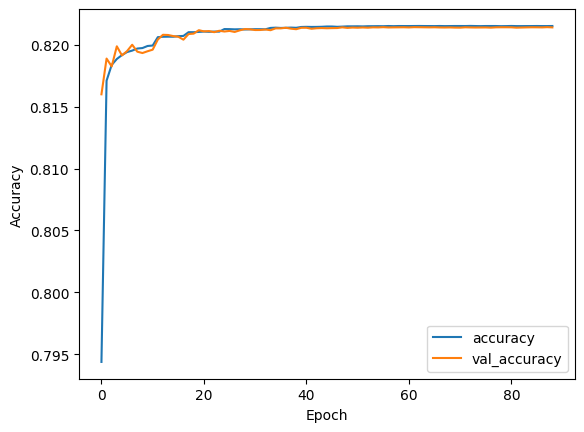

In [33]:
#plotting the accuracy of the first model
import matplotlib.pyplot as plt
plt.plot(history1.history['accuracy'], label='accuracy')
plt.plot(history1.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

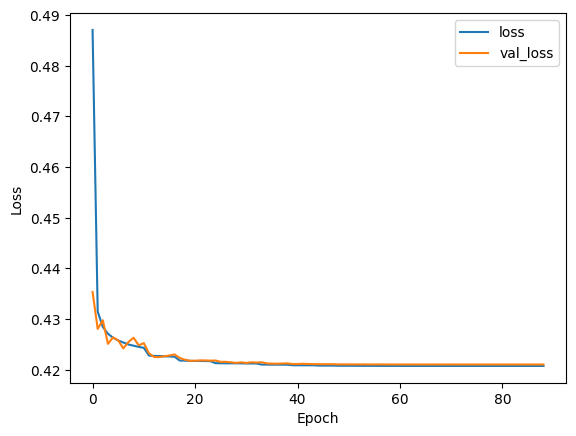

In [34]:
#plotting the loss over epoch for the first model
plt.plot(history1.history['loss'], label='loss')
plt.plot(history1.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [35]:
#save the first trained model
model1.save('../models/model_SimpleRNN_214.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [36]:
# Train model 2
history2 = model2.fit(X2_seq_train, y2_seq_train, epochs=200, batch_size=256, verbose=2,
                      validation_data=(X2_seq_val, y2_seq_val),
                      callbacks=callbacks)

Epoch 1/200
8644/8644 - 135s - loss: 0.5048 - accuracy: 0.7869 - val_loss: 0.4479 - val_accuracy: 0.8104 - lr: 0.0010 - 135s/epoch - 16ms/step
Epoch 2/200
8644/8644 - 132s - loss: 0.4345 - accuracy: 0.8159 - val_loss: 0.4294 - val_accuracy: 0.8178 - lr: 0.0010 - 132s/epoch - 15ms/step
Epoch 3/200
8644/8644 - 132s - loss: 0.4285 - accuracy: 0.8183 - val_loss: 0.4270 - val_accuracy: 0.8191 - lr: 0.0010 - 132s/epoch - 15ms/step
Epoch 4/200
8644/8644 - 131s - loss: 0.4272 - accuracy: 0.8188 - val_loss: 0.4273 - val_accuracy: 0.8176 - lr: 0.0010 - 131s/epoch - 15ms/step
Epoch 5/200
8644/8644 - 132s - loss: 0.4264 - accuracy: 0.8191 - val_loss: 0.4258 - val_accuracy: 0.8187 - lr: 0.0010 - 132s/epoch - 15ms/step
Epoch 6/200
8644/8644 - 132s - loss: 0.4259 - accuracy: 0.8194 - val_loss: 0.4269 - val_accuracy: 0.8186 - lr: 0.0010 - 132s/epoch - 15ms/step
Epoch 7/200
8644/8644 - 132s - loss: 0.4255 - accuracy: 0.8195 - val_loss: 0.4261 - val_accuracy: 0.8194 - lr: 0.0010 - 132s/epoch - 15ms/step

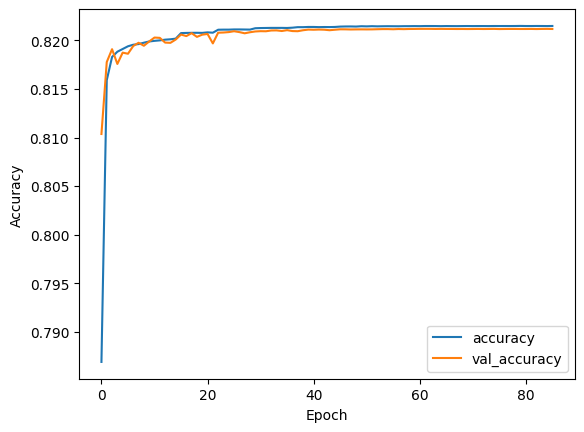

In [37]:
#plotting the accuracy of the second model
import matplotlib.pyplot as plt
plt.plot(history2.history['accuracy'], label='accuracy')
plt.plot(history2.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

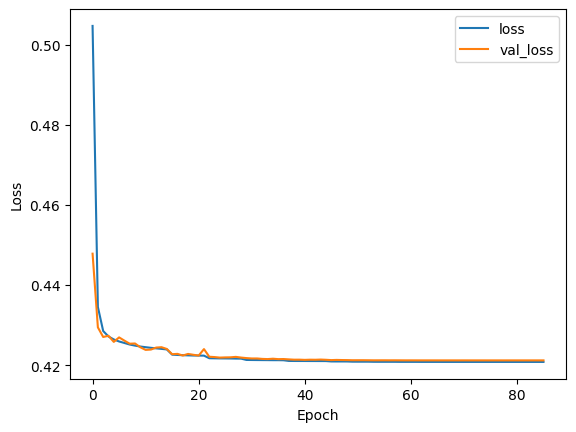

In [38]:
#plotting the loss over epoch for the second model
plt.plot(history2.history['loss'], label='loss')
plt.plot(history2.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [39]:
#save the second trained model
model2.save('../models/model_SimpleRNN_212.h5')